In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from figures_setup import *
from utils import set_color_code

## Read data: biobank subcut epi

In [3]:
# Read input data
file = os.path.join(dir_data, "biobank_subcut_epi.h5ad")
adata = sc.read_h5ad(file)

## Annotation

In [4]:
# Add annotation
from utils_biobank_subcut import anno_leiden_dict_epi as anno_leiden_dict

if adata.uns['leiden']['params']['resolution'] == anno_leiden_dict['resolution']:
    adata.obs['anno'] = adata.obs['leiden'].map(anno_leiden_dict['labels'])
else:
    raise ValueError("Resolution mismatch between adata.uns['leiden'] and anno_leiden_dict.")

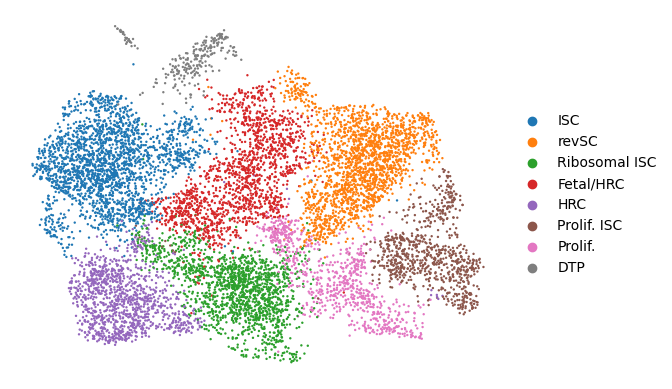

In [11]:
# Annotation UMAP
sc.pl.umap(adata, color=['anno'], frameon=False, title='')

In [5]:
### Infer cell cycle phase
import utils_genelist as genelist

print("Infer cell cycle phase...")
# Get cell-cycle related gene sets
geneset = genelist.get_Tirosh_2016()
sc.tl.score_genes_cell_cycle(adata, 
                        s_genes=genelist.strip_gene_list(geneset['G1/S']), 
                        g2m_genes=genelist.strip_gene_list(geneset['G2/M']))

Infer cell cycle phase...


/omics/groups/OE0285/internal/puschhof/github_projects/TROP2_in_CRC/figures/utils_genelist.py:25: UserWarning: Removed columns containing only NaNs: Unnamed: 7, Unnamed: 8, Unnamed: 9, Unnamed: 10, Unnamed: 11, Unnamed: 12, Unnamed: 13, Unnamed: 14, Unnamed: 15, Unnamed: 16
  warnings.warn(f"Removed columns containing only NaNs: {', '.join(cols_to_remove)}")


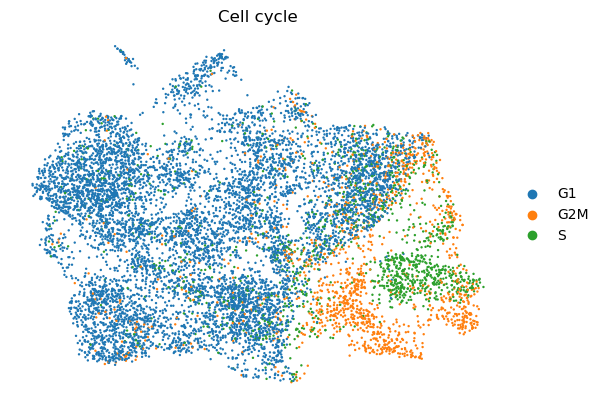

In [6]:
# Cell cycle UMAP
sc.pl.umap(adata, color=['phase'], frameon=False, title='Cell cycle')

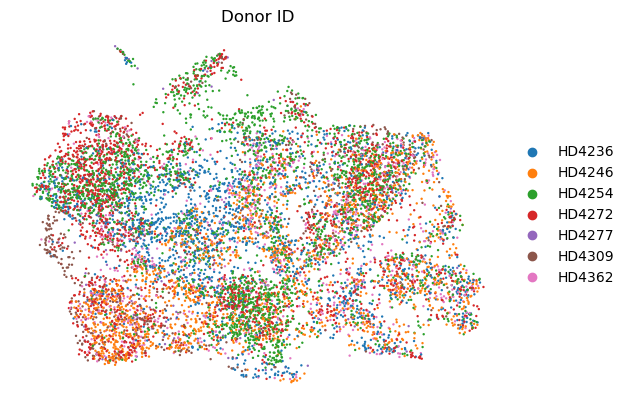

In [6]:
# Donor id UMAP
sc.pl.umap(adata, color=['donor_id'], frameon=False, title='Donor ID')

## Gene expression UMAP

UMAPs of gene expression patterns:


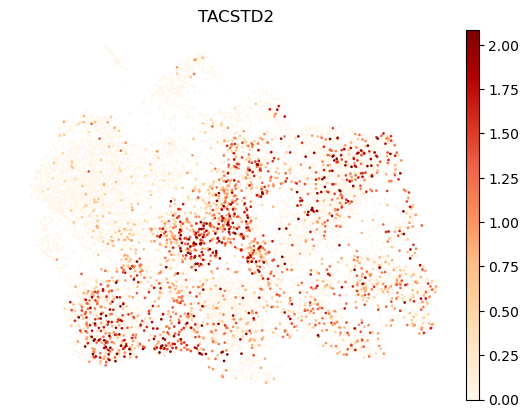

<Figure size 640x480 with 0 Axes>

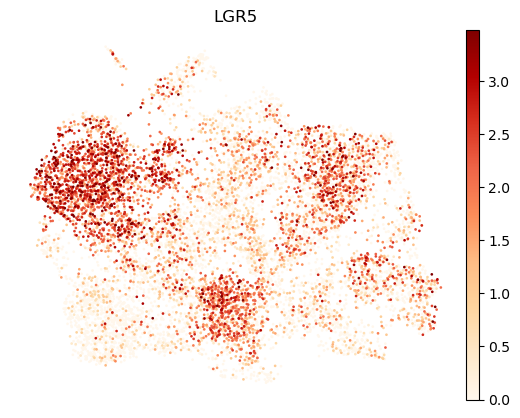

<Figure size 640x480 with 0 Axes>

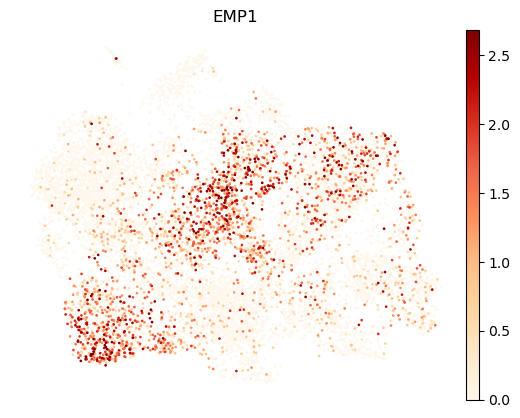

<Figure size 640x480 with 0 Axes>

In [16]:
# Features to plot
features = ['TACSTD2', 'LGR5', 'EMP1']

# Define plotting parameters
vmax = 'p99'
dot_size = 120000 / adata.shape[0] * 1.25 # size factor of 1.25 here, also done 1.0 and 1.5 (previously)

# Make UMAPs of gene set scores
print("UMAPs of gene expression patterns:")
for feature in features:    
    # Plot and save UMAPs
    sc.pl.umap(adata, color=feature, size=dot_size, cmap='OrRd', vmax=vmax, frameon=False)
    plt.tight_layout()
    plt.show()

## Gene set activation scores

In [7]:
# Import literature gene sets to adata
from utils import get_gene_sets
print("Importing gene sets into anndata object...")
adata = get_gene_sets(adata)

Importing gene sets into anndata object...
Get Gregorieff YAP gene set
Genes with opposing directionality in YapKO and YapOE will be filtered out.
Genes with an absolute fold change of log2(1.2) will be kept.
97.95% of the geneset score_YAP (1192 out of 1217 genes) are included in dataset.
Process fetal gene set
96.18% of the geneset score_fetal (252 out of 262 genes) are included in dataset.
Process LGR5 gene set
97.87% of the geneset score_Lgr5 (321 out of 328 genes) are included in dataset.
Process Ganesh gene set collection
86.74% of the geneset score_squamous_Moorman (242 out of 279 genes) are included in dataset.
84.31% of the geneset score_neuroendocrine_Moorman (129 out of 153 genes) are included in dataset.
96.46% of the geneset score_fetal_Moorman (109 out of 113 genes) are included in dataset.
Process EMP1-related gene sets
91.65% of the geneset score_allHR (2317 out of 2528 genes) are included in dataset.
95.00% of the geneset score_coreHR (95 out of 100 genes) are included

In [8]:
# Compute gene set scores
gs_process = ['score_fetal', 'score_Lgr5', 'score_epiHR']
feature_labels = {
    'score_fetal': 'Fetal',
    'score_Lgr5': 'ISC',
    'score_epiHR': 'EpiHR',
}

import utils_genelist as genelist

gene_sets = adata.uns['gene_sets']
for score_name in gs_process:
    genes = gene_sets[gene_sets['gene_set'] == score_name]['gene']
    adata = genelist.compute_gene_score(adata, genes, score_name=score_name)

Using adata.raw for gene score computation.
Compute gene score for score_fetal
Using adata.raw for gene score computation.
Compute gene score for score_Lgr5
Using adata.raw for gene score computation.
Compute gene score for score_epiHR


UMAPs of gene set scores:


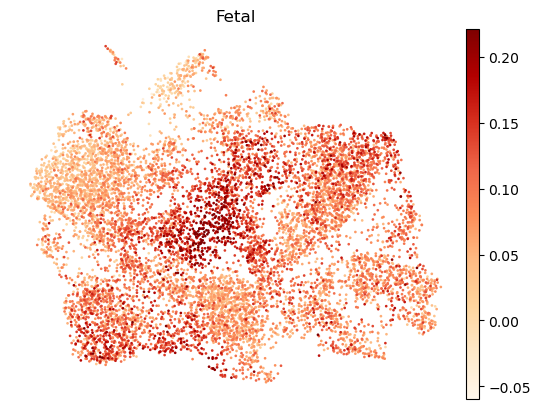

<Figure size 640x480 with 0 Axes>

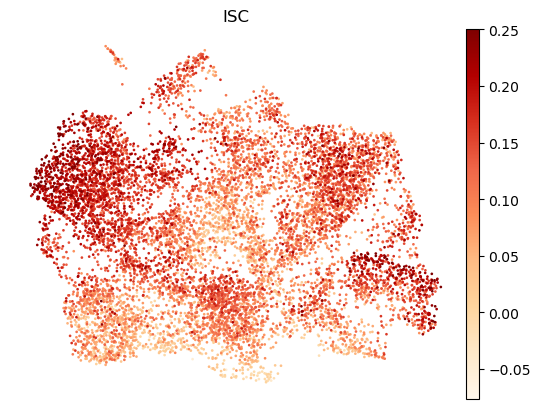

<Figure size 640x480 with 0 Axes>

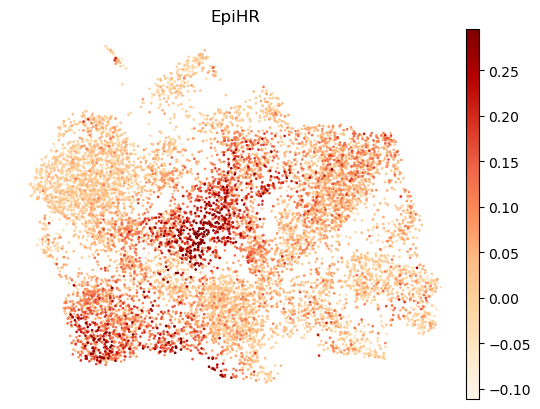

<Figure size 640x480 with 0 Axes>

In [9]:
# Define plotting parameters
vmax = 'p99'
dot_size = 120000 / adata.shape[0] * 1.25 # size factor of 1.25 here, also done 1.0 and 1.5 (previously)

# Make UMAPs of gene set scores
print("UMAPs of gene set scores:")
for feature in gs_process:    
    # Plot and save UMAPs
    sc.pl.umap(adata, color=feature, size=dot_size,
               title=feature_labels[feature], 
               cmap='OrRd', vmax=vmax, frameon=False)
    plt.tight_layout()
    plt.show()

## Stem cell composition

In [5]:
# Add LGR5 / TROP2 status
from utils import add_SC_status
adata = add_SC_status(adata)

In [7]:
# Set color code and plot barplot
from utils_biobank_subcut import color_code
adata = set_color_code(adata, color_code, feature='SC_status')

/tmp/ipykernel_422833/867165235.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(groupby)['SC_status']


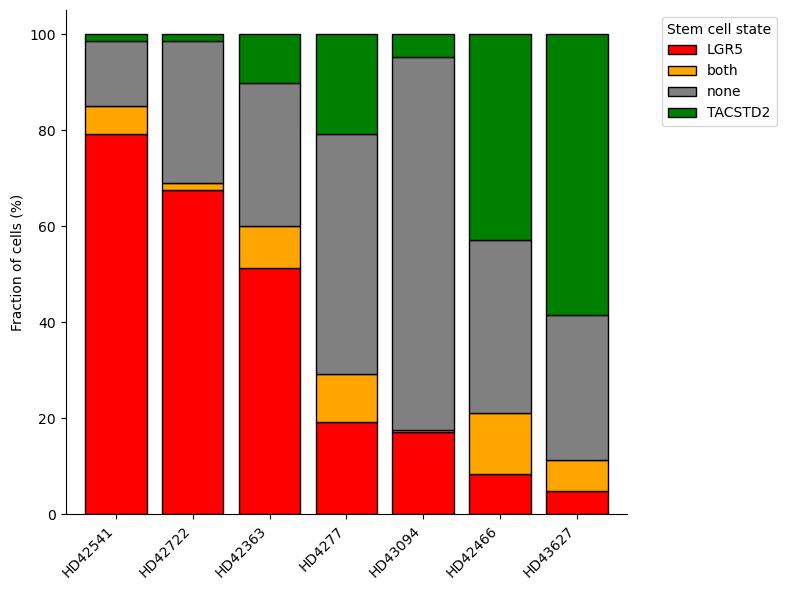

In [8]:
groupby = 'donor_id'

# Map full donor IDs
from utils import full_donor_id_dict
# from utils_biobank_tissue import order_donor_id

# SC status as bar graph by grouping parameter
df = (
    adata.obs.groupby(groupby)['SC_status']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    *100 # percentage values
)

# Sort the DataFrame based on LGR5 levels in descending order
df = df.sort_values(by='LGR5', ascending=False)
# # Sort DataFrame based on predefined donor order
# df = df.reindex(order_donor_id)

# Barplot mimicking Fig S1N
# Values were plotted with GraphPad Prism in the original figure
ax = df.plot(
    kind='bar', 
    stacked=True, 
    edgecolor='black',
    color=color_code['SC_status']['colors'],
    figsize=(8, 6), 
    width=0.8,
)
plt.xlabel('')
plt.ylabel('Fraction of cells (%)')
# Change x-ticks and labels
ax.set_xticklabels([full_donor_id_dict.get(donor, donor) for donor in df.index])
plt.xticks(rotation=45, ha='right')
plt.legend(title='Stem cell state', bbox_to_anchor=(1.05, 1), loc='upper left')
# Remove box frame, keep axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## EMP1 TACSTD2 composition

In [9]:
# Add EMP1 / TROP2 status
from utils import add_EMP1_status
adata = add_EMP1_status(adata)

In [16]:
# Set color code and plot barplot
from utils_biobank_subcut import color_code
adata = set_color_code(adata, color_code, feature='EMP1_status')

/tmp/ipykernel_422833/2817176025.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(groupby)['EMP1_status']


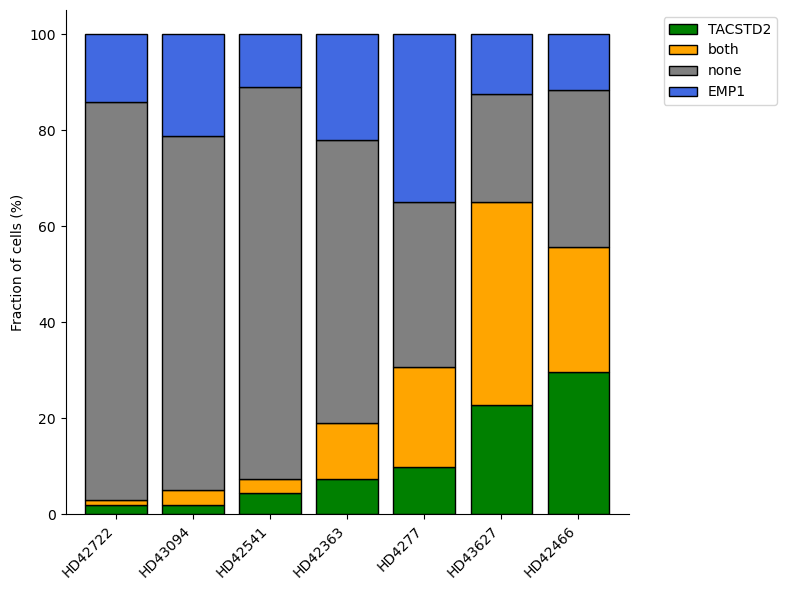

In [17]:
groupby = 'donor_id'

# Map full donor IDs
from utils import full_donor_id_dict
# from utils_biobank_tissue import order_donor_id

# SC status as bar graph by grouping parameter
df = (
    adata.obs.groupby(groupby)['EMP1_status']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    *100 # percentage values
)

# Sort the DataFrame based on TACSTD2 levels in ascending order
df = df.sort_values(by='TACSTD2', ascending=True)
# # Sort DataFrame based on predefined donor order
# df = df.reindex(order_donor_id)

# Barplot mimicking Fig S1N
# Values were plotted with GraphPad Prism in the original figure
ax = df.plot(
    kind='bar', 
    stacked=True, 
    edgecolor='black',
    color=color_code['EMP1_status']['colors'],
    figsize=(8, 6), 
    width=0.8,
)
plt.xlabel('')
plt.ylabel('Fraction of cells (%)')
# Change x-ticks and labels
ax.set_xticklabels([full_donor_id_dict.get(donor, donor) for donor in df.index])
plt.xticks(rotation=45, ha='right')
plt.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left')
# Remove box frame, keep axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Gene set enrichment TROP2+ vs TROP2- 

### Pseudobulk generation (tbc)

In [ ]:
# Gene set enrichment plot (NES)